In [2]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [3]:
transform = transforms.ToTensor()

train_dataset = torchvision.datasets.MNIST(
    root='./data', train=True, transform=transform, download=True)

test_dataset = torchvision.datasets.MNIST(
    root='./data', train=False, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.09MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 134kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.26MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.09MB/s]


In [4]:
class CNN_LSTM(nn.Module):
    def __init__(self):
        super(CNN_LSTM, self).__init__()

        # CNN feature extractor
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 28 → 14

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)    # 14 → 7
        )

        # LSTM
        self.lstm = nn.LSTM(input_size=64*7, hidden_size=128, batch_first=True)

        # Output
        self.fc = nn.Linear(128, 10)

    def forward(self, x):
        x = self.cnn(x)   # (B, 64, 7, 7)

        # reshape for LSTM
        x = x.permute(0, 2, 1, 3)  # (B, 7, 64, 7)
        x = x.reshape(x.size(0), 7, -1)  # (B, 7, 64*7)

        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])

        return out

In [5]:
model = CNN_LSTM().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [6]:
num_epochs = 3

start = time.time()

for epoch in range(num_epochs):
    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")

print("Training Time:", time.time() - start)

Epoch [1/3], Loss: 0.0156
Epoch [2/3], Loss: 0.0225
Epoch [3/3], Loss: 0.0259
Training Time: 31.570314407348633


In [7]:
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy: {100 * correct / total:.2f}%')

Accuracy: 98.91%


In [8]:
class TD_CNN_LSTM(nn.Module):
    def __init__(self):
        super(TD_CNN_LSTM, self).__init__()

        self.cnn = nn.Sequential(
            nn.Conv2d(1, 16, (1,3), padding=(0,1)),
            nn.ReLU()
        )

        self.lstm = nn.LSTM(16*28, 128, batch_first=True)
        self.fc = nn.Linear(128, 10)

    def forward(self, x):
        B = x.size(0)

        x = x.squeeze(1)  # (B,28,28)

        rows = []
        for i in range(28):
            row = x[:, i, :].unsqueeze(1).unsqueeze(2)  # (B,1,1,28)
            feat = self.cnn(row)  # (B,16,1,28)
            feat = feat.view(B, -1)
            rows.append(feat)

        x_seq = torch.stack(rows, dim=1)

        out, _ = self.lstm(x_seq)
        out = self.fc(out[:, -1, :])

        return out

In [9]:
model = TD_CNN_LSTM().to(device)

In [10]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [11]:
num_epochs = 3

import time
start = time.time()

for epoch in range(num_epochs):
    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        # forward
        outputs = model(images)
        loss = criterion(outputs, labels)

        # backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")

print("Training Time:", time.time() - start)

Epoch [1/3], Loss: 0.0710
Epoch [2/3], Loss: 0.0205
Epoch [3/3], Loss: 0.0064
Training Time: 48.89938569068909


In [12]:
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy: {100 * correct / total:.2f}%')

Accuracy: 97.74%


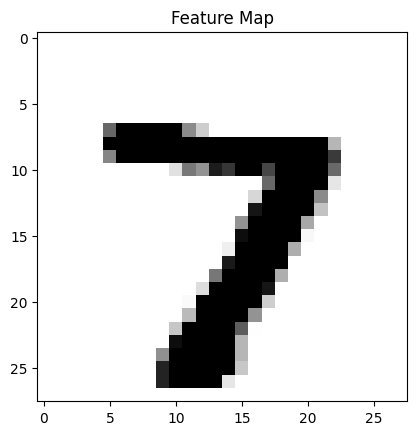

In [13]:
# visualize CNN features
sample, _ = next(iter(test_loader))
sample = sample.to(device)

features = model.cnn(sample[:1])

plt.imshow(features[0,0].cpu().detach(), cmap='gray')
plt.title("Feature Map")
plt.show()

In [14]:
total_params = sum(p.numel() for p in model.parameters())
print("Total Parameters:", total_params)

Total Parameters: 297290
